**Un algoritmo simplificado DeepC para sistema lineal**

alejandro.garces@utp.edu.co

Agosto 2026

In [1]:
using LinearAlgebra
using Plots
using JuMP
using Ipopt

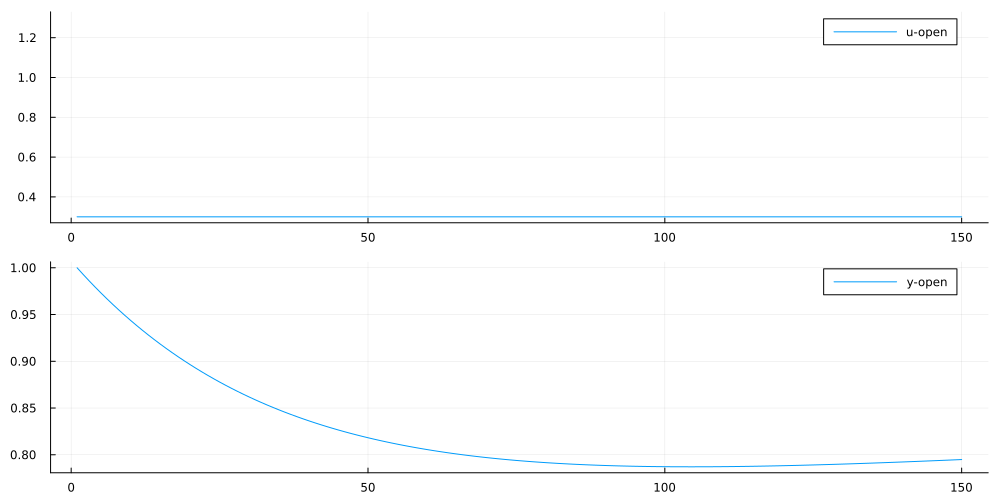

In [2]:
# Sistema lineal a analizar
nh = 10 # datos historicos, etapa de aprendizaje
dt = 0.01
Ac = [0 -1; 1 -3]
Bc = [1;0]
A = [1 0; 0 1] + dt*Ac
B = dt*Bc
C = [1 0]
D = [0]
nt = 150
xt = ones(2,nt)
ut = ones(nt)*0.3
for k = 2:nt
    xt[:,k] = A*xt[:,k-1]+B*ut[k]
end
yt = C*xt
p1 = plot(ut,label="u-open")
p2 = plot(yt',label="y-open")
plot(p1,p2,layout=(2,1),size=(1000,500))

In [5]:
function DeepC(uh,yh,Q,R)
    nh = length(uh) # historial disponible
    nc = 2
    np = nh-nc      # trayectorias a suponer
    Modelo = Model(Ipopt.Optimizer)
    @variable(Modelo,u)
    @variable(Modelo,y)  # ver un paso hacia adelante
    @variable(Modelo,g[1:np])
    for k = nh:-1:(nh-nc+1) # hacia atras
        @constraint(Modelo,uh[k] == sum(g.*uh[(k-1):-1:(k-np)]))
        @constraint(Modelo,yh[k] == sum(g.*yh[(k-1):-1:(k-np)]))
    end
    @constraint(Modelo,u == sum(g.*uh[nh:-1:(nh+1-np)]))
    @constraint(Modelo,y == sum(g.*yh[nh:-1:(nh+1-np)]))
    @objective(Modelo,Min,1/2*Q*(y)'*(y)+1/2*R*u'*u+0.0001*g'*g)
    #@constraint(Modelo,u.>=-1)
    #@constraint(Modelo,u.<= 1)
    set_silent(Modelo)
    optimize!(Modelo)
    termination_status(Modelo)==INVALID_MODEL &&  println("Modelo invalido") ;
    return value.(u)
end
Q = 2000
R = 1
yref = 0.9
uref = 0.3
DeepC(ut[1:nh].-uref,yt[1:nh].-yref,Q,R)

0.0

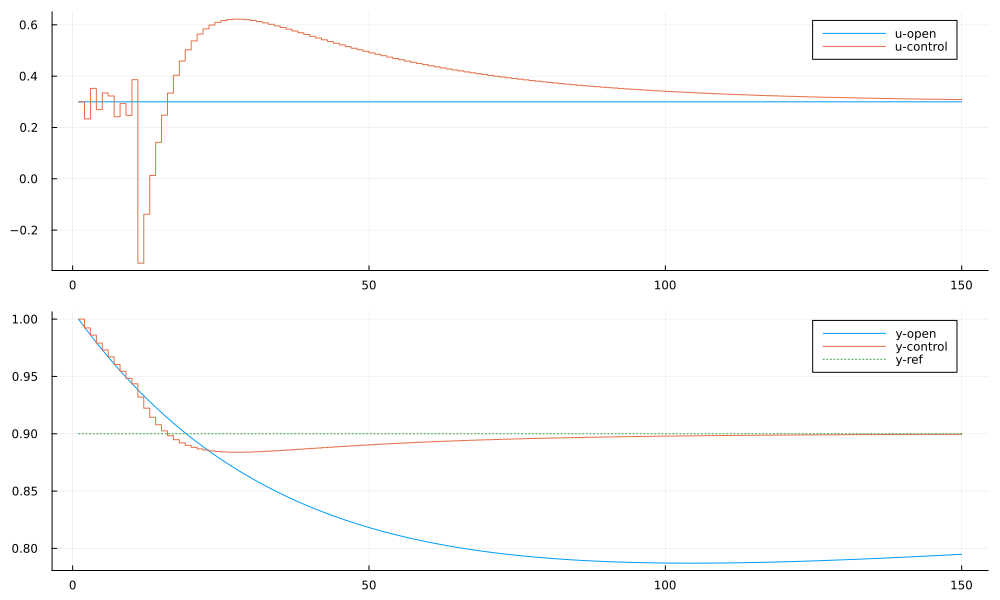

In [6]:
#Control
xcontrol = xt[:,:]
ucontrol = ut[:]
ycontrol = yt[:] 
for k = 2:nt
    if k<=nh
        local Δu = 0.05*randn()  # Zona aleatoria para entrenar el modelo
    else
        local Δu = DeepC(ucontrol[(k-nh):(k-1)].-uref,ycontrol[(k-nh):(k-1)].-yref,Q,R)
    end
    ucontrol[k]   = Δu[1]+uref
    xcontrol[:,k] = A*xcontrol[:,k-1] + B*ucontrol[k]
    ycontrol[k]   = (C*xcontrol[:,k])[1]
end
plt1 = plot(p1,ucontrol,label="u-control",st=:steppost)
plt2 = plot(p2,ycontrol,label="y-control",st=:steppost)
plt2 = plot(plt2,ones(nt)*yref,label="y-ref",linestyle=:dot)
plot(plt1,plt2,layout=(2,1),size=(1000,600))